# 02. Model Architecture Analysis

Visualisasi dan analisis arsitektur model untuk paper.

**Contents:**
- Ghost Module vs Standard Convolution
- Coordinate Attention Mechanism
- Model Comparison (ResNet vs GhostResNet)
- Parameter & FLOPs Analysis

In [1]:
import sys
sys.path.append('..')

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

from models import create_model, get_model_info
from models.layers.ghost_module import GhostModule
from models.layers.attention import CoordinateAttention, SEAttention

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


## 1. Ghost Module vs Standard Convolution

Ghost Module generates feature maps with fewer parameters by:
1. Primary convolution: generates intrinsic features (fewer channels)
2. Cheap operations: generates ghost features via depthwise convolution

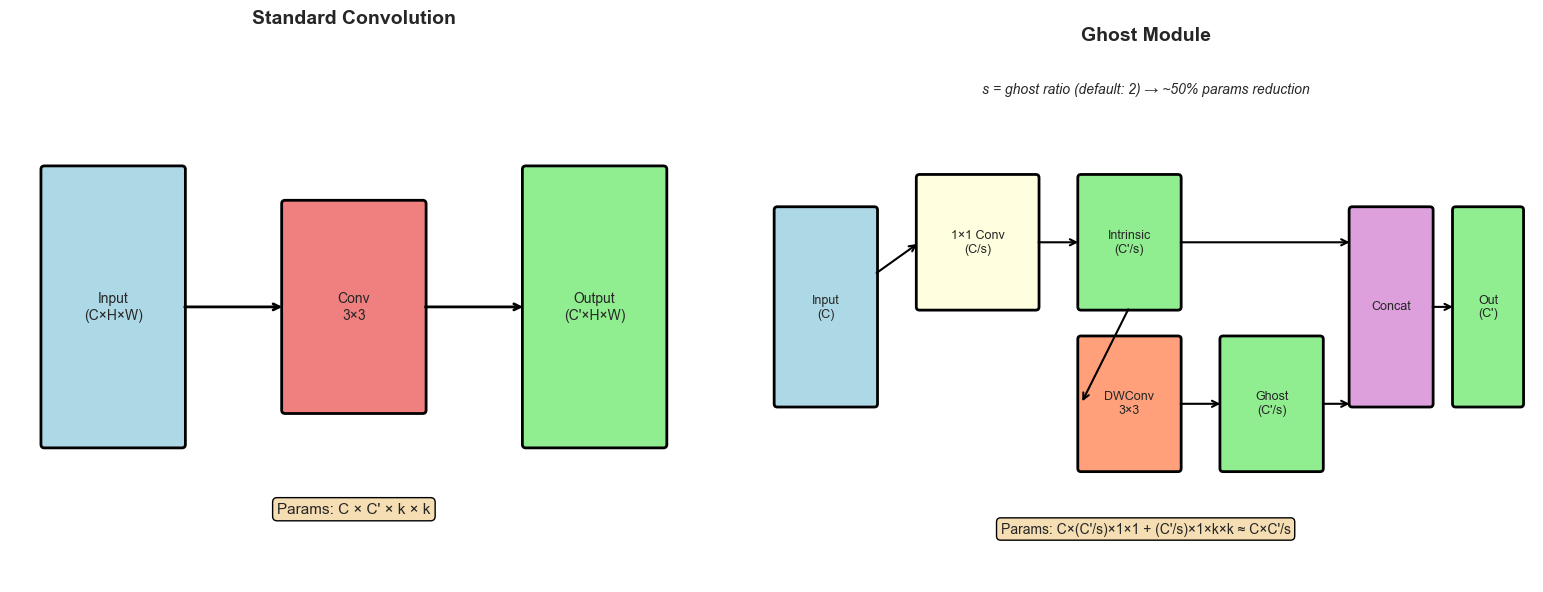

In [2]:
def visualize_ghost_module():
    """Visualize Ghost Module architecture"""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Standard Convolution
    ax = axes[0]
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 8)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title('Standard Convolution', fontsize=14, fontweight='bold')
    
    # Input
    ax.add_patch(FancyBboxPatch((0.5, 2), 2, 4, boxstyle="round,pad=0.05",
                                 facecolor='lightblue', edgecolor='black', linewidth=2))
    ax.text(1.5, 4, 'Input\n(C×H×W)', ha='center', va='center', fontsize=10)
    
    # Conv
    ax.add_patch(FancyBboxPatch((4, 2.5), 2, 3, boxstyle="round,pad=0.05",
                                 facecolor='lightcoral', edgecolor='black', linewidth=2))
    ax.text(5, 4, 'Conv\n3×3', ha='center', va='center', fontsize=10)
    
    # Output
    ax.add_patch(FancyBboxPatch((7.5, 2), 2, 4, boxstyle="round,pad=0.05",
                                 facecolor='lightgreen', edgecolor='black', linewidth=2))
    ax.text(8.5, 4, 'Output\n(C\'×H×W)', ha='center', va='center', fontsize=10)
    
    # Arrows
    ax.annotate('', xy=(4, 4), xytext=(2.5, 4),
                arrowprops=dict(arrowstyle='->', lw=2))
    ax.annotate('', xy=(7.5, 4), xytext=(6, 4),
                arrowprops=dict(arrowstyle='->', lw=2))
    
    # Parameters
    ax.text(5, 1, 'Params: C × C\' × k × k', ha='center', fontsize=11, 
            bbox=dict(boxstyle='round', facecolor='wheat'))
    
    # Ghost Module
    ax = axes[1]
    ax.set_xlim(0, 12)
    ax.set_ylim(0, 8)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title('Ghost Module', fontsize=14, fontweight='bold')
    
    # Input
    ax.add_patch(FancyBboxPatch((0.3, 2.5), 1.5, 3, boxstyle="round,pad=0.05",
                                 facecolor='lightblue', edgecolor='black', linewidth=2))
    ax.text(1.05, 4, 'Input\n(C)', ha='center', va='center', fontsize=9)
    
    # Primary Conv (1x1)
    ax.add_patch(FancyBboxPatch((2.5, 4), 1.8, 2, boxstyle="round,pad=0.05",
                                 facecolor='lightyellow', edgecolor='black', linewidth=2))
    ax.text(3.4, 5, '1×1 Conv\n(C/s)', ha='center', va='center', fontsize=9)
    
    # Intrinsic features
    ax.add_patch(FancyBboxPatch((5, 4), 1.5, 2, boxstyle="round,pad=0.05",
                                 facecolor='lightgreen', edgecolor='black', linewidth=2))
    ax.text(5.75, 5, 'Intrinsic\n(C\'/s)', ha='center', va='center', fontsize=9)
    
    # Cheap operation (DWConv)
    ax.add_patch(FancyBboxPatch((5, 1.5), 1.5, 2, boxstyle="round,pad=0.05",
                                 facecolor='lightsalmon', edgecolor='black', linewidth=2))
    ax.text(5.75, 2.5, 'DWConv\n3×3', ha='center', va='center', fontsize=9)
    
    # Ghost features
    ax.add_patch(FancyBboxPatch((7.2, 1.5), 1.5, 2, boxstyle="round,pad=0.05",
                                 facecolor='lightgreen', edgecolor='black', linewidth=2))
    ax.text(7.95, 2.5, 'Ghost\n(C\'/s)', ha='center', va='center', fontsize=9)
    
    # Concat
    ax.add_patch(FancyBboxPatch((9.2, 2.5), 1.2, 3, boxstyle="round,pad=0.05",
                                 facecolor='plum', edgecolor='black', linewidth=2))
    ax.text(9.8, 4, 'Concat', ha='center', va='center', fontsize=9)
    
    # Output
    ax.add_patch(FancyBboxPatch((10.8, 2.5), 1, 3, boxstyle="round,pad=0.05",
                                 facecolor='lightgreen', edgecolor='black', linewidth=2))
    ax.text(11.3, 4, 'Out\n(C\')', ha='center', va='center', fontsize=9)
    
    # Arrows
    ax.annotate('', xy=(2.5, 5), xytext=(1.8, 4.5), arrowprops=dict(arrowstyle='->', lw=1.5))
    ax.annotate('', xy=(5, 5), xytext=(4.3, 5), arrowprops=dict(arrowstyle='->', lw=1.5))
    ax.annotate('', xy=(5, 2.5), xytext=(5.75, 4), arrowprops=dict(arrowstyle='->', lw=1.5))
    ax.annotate('', xy=(7.2, 2.5), xytext=(6.5, 2.5), arrowprops=dict(arrowstyle='->', lw=1.5))
    ax.annotate('', xy=(9.2, 5), xytext=(6.5, 5), arrowprops=dict(arrowstyle='->', lw=1.5))
    ax.annotate('', xy=(9.2, 2.5), xytext=(8.7, 2.5), arrowprops=dict(arrowstyle='->', lw=1.5))
    ax.annotate('', xy=(10.8, 4), xytext=(10.4, 4), arrowprops=dict(arrowstyle='->', lw=1.5))
    
    # Parameters
    ax.text(6, 0.5, 'Params: C×(C\'/s)×1×1 + (C\'/s)×1×k×k ≈ C×C\'/s', 
            ha='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat'))
    ax.text(6, 7.3, 's = ghost ratio (default: 2) → ~50% params reduction', 
            ha='center', fontsize=10, style='italic')
    
    plt.tight_layout()
    plt.savefig('../weights/ghost_module_diagram.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_ghost_module()

In [3]:
# Compare parameters: Standard Conv vs Ghost Module
in_channels = 64
out_channels = 128
kernel_size = 3

# Standard Conv
std_conv = nn.Conv2d(in_channels, out_channels, kernel_size, padding=1, bias=False)
std_params = sum(p.numel() for p in std_conv.parameters())

# Ghost Module
ghost = GhostModule(in_channels, out_channels, kernel_size=1, ratio=2)
ghost_params = sum(p.numel() for p in ghost.parameters())

print(f"{'='*50}")
print(f"Parameter Comparison (in={in_channels}, out={out_channels})")
print(f"{'='*50}")
print(f"Standard Conv 3×3: {std_params:,} params")
print(f"Ghost Module:      {ghost_params:,} params")
print(f"Reduction:         {(1 - ghost_params/std_params)*100:.1f}%")
print(f"Ratio:             {std_params/ghost_params:.2f}x")

Parameter Comparison (in=64, out=128)
Standard Conv 3×3: 73,728 params
Ghost Module:      4,928 params
Reduction:         93.3%
Ratio:             14.96x


## 2. Coordinate Attention Mechanism

Coordinate Attention captures long-range dependencies with positional information:
1. X-pooling & Y-pooling (preserve spatial info)
2. Shared 1×1 Conv + BN + Activation
3. Separate 1×1 Conv for H and W attention

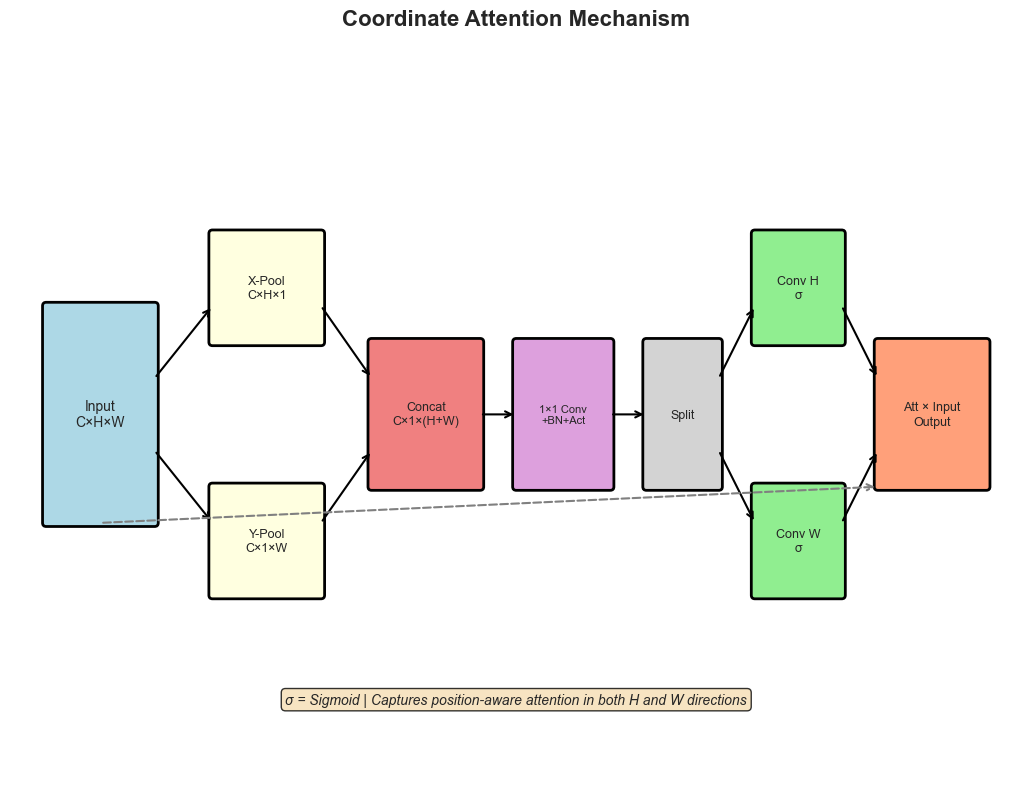

In [4]:
def visualize_coordinate_attention():
    """Visualize Coordinate Attention mechanism"""
    fig, ax = plt.subplots(1, 1, figsize=(14, 8))
    ax.set_xlim(0, 14)
    ax.set_ylim(0, 10)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title('Coordinate Attention Mechanism', fontsize=16, fontweight='bold', pad=20)
    
    # Input feature map
    ax.add_patch(FancyBboxPatch((0.5, 3.5), 1.5, 3, boxstyle="round,pad=0.05",
                                 facecolor='lightblue', edgecolor='black', linewidth=2))
    ax.text(1.25, 5, 'Input\nC×H×W', ha='center', va='center', fontsize=10)
    
    # X-Pool (H direction)
    ax.add_patch(FancyBboxPatch((2.8, 6), 1.5, 1.5, boxstyle="round,pad=0.05",
                                 facecolor='lightyellow', edgecolor='black', linewidth=2))
    ax.text(3.55, 6.75, 'X-Pool\nC×H×1', ha='center', va='center', fontsize=9)
    
    # Y-Pool (W direction)
    ax.add_patch(FancyBboxPatch((2.8, 2.5), 1.5, 1.5, boxstyle="round,pad=0.05",
                                 facecolor='lightyellow', edgecolor='black', linewidth=2))
    ax.text(3.55, 3.25, 'Y-Pool\nC×1×W', ha='center', va='center', fontsize=9)
    
    # Concat + Transpose
    ax.add_patch(FancyBboxPatch((5, 4), 1.5, 2, boxstyle="round,pad=0.05",
                                 facecolor='lightcoral', edgecolor='black', linewidth=2))
    ax.text(5.75, 5, 'Concat\nC×1×(H+W)', ha='center', va='center', fontsize=9)
    
    # Shared Conv
    ax.add_patch(FancyBboxPatch((7, 4), 1.3, 2, boxstyle="round,pad=0.05",
                                 facecolor='plum', edgecolor='black', linewidth=2))
    ax.text(7.65, 5, '1×1 Conv\n+BN+Act', ha='center', va='center', fontsize=8)
    
    # Split
    ax.add_patch(FancyBboxPatch((8.8, 4), 1, 2, boxstyle="round,pad=0.05",
                                 facecolor='lightgray', edgecolor='black', linewidth=2))
    ax.text(9.3, 5, 'Split', ha='center', va='center', fontsize=9)
    
    # Conv H
    ax.add_patch(FancyBboxPatch((10.3, 6), 1.2, 1.5, boxstyle="round,pad=0.05",
                                 facecolor='lightgreen', edgecolor='black', linewidth=2))
    ax.text(10.9, 6.75, 'Conv H\nσ', ha='center', va='center', fontsize=9)
    
    # Conv W
    ax.add_patch(FancyBboxPatch((10.3, 2.5), 1.2, 1.5, boxstyle="round,pad=0.05",
                                 facecolor='lightgreen', edgecolor='black', linewidth=2))
    ax.text(10.9, 3.25, 'Conv W\nσ', ha='center', va='center', fontsize=9)
    
    # Attention weights
    ax.add_patch(FancyBboxPatch((12, 4), 1.5, 2, boxstyle="round,pad=0.05",
                                 facecolor='lightsalmon', edgecolor='black', linewidth=2))
    ax.text(12.75, 5, 'Att × Input\nOutput', ha='center', va='center', fontsize=9)
    
    # Arrows
    ax.annotate('', xy=(2.8, 6.5), xytext=(2, 5.5), arrowprops=dict(arrowstyle='->', lw=1.5))
    ax.annotate('', xy=(2.8, 3.5), xytext=(2, 4.5), arrowprops=dict(arrowstyle='->', lw=1.5))
    ax.annotate('', xy=(5, 5.5), xytext=(4.3, 6.5), arrowprops=dict(arrowstyle='->', lw=1.5))
    ax.annotate('', xy=(5, 4.5), xytext=(4.3, 3.5), arrowprops=dict(arrowstyle='->', lw=1.5))
    ax.annotate('', xy=(7, 5), xytext=(6.5, 5), arrowprops=dict(arrowstyle='->', lw=1.5))
    ax.annotate('', xy=(8.8, 5), xytext=(8.3, 5), arrowprops=dict(arrowstyle='->', lw=1.5))
    ax.annotate('', xy=(10.3, 6.5), xytext=(9.8, 5.5), arrowprops=dict(arrowstyle='->', lw=1.5))
    ax.annotate('', xy=(10.3, 3.5), xytext=(9.8, 4.5), arrowprops=dict(arrowstyle='->', lw=1.5))
    ax.annotate('', xy=(12, 5.5), xytext=(11.5, 6.5), arrowprops=dict(arrowstyle='->', lw=1.5))
    ax.annotate('', xy=(12, 4.5), xytext=(11.5, 3.5), arrowprops=dict(arrowstyle='->', lw=1.5))
    
    # Skip connection from input
    ax.annotate('', xy=(12, 4), xytext=(1.25, 3.5),
                arrowprops=dict(arrowstyle='->', lw=1.5, linestyle='--', color='gray'))
    
    # Legend
    ax.text(7, 1, 'σ = Sigmoid | Captures position-aware attention in both H and W directions', 
            ha='center', fontsize=10, style='italic',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    plt.savefig('../weights/coordinate_attention_diagram.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_coordinate_attention()

In [5]:
# Compare attention mechanisms
channels = 64
reduction = 16

se = SEAttention(channels, reduction)
coord = CoordinateAttention(channels, channels, reduction)

se_params = sum(p.numel() for p in se.parameters())
coord_params = sum(p.numel() for p in coord.parameters())

print(f"{'='*50}")
print(f"Attention Mechanism Comparison (C={channels})")
print(f"{'='*50}")
print(f"SE Attention:         {se_params:,} params")
print(f"Coordinate Attention: {coord_params:,} params")
print(f"\nCoordinate Attention advantage:")
print(f"  • Captures spatial (positional) information")
print(f"  • Separate attention for H and W directions")
print(f"  • Better for object detection & segmentation")

Attention Mechanism Comparison (C=64)
SE Attention:         512 params
Coordinate Attention: 1,688 params

Coordinate Attention advantage:
  • Captures spatial (positional) information
  • Separate attention for H and W directions
  • Better for object detection & segmentation


## 3. Model Architecture Comparison

In [6]:
# Create models for comparison
models_config = [
    ('ResNet-18', 'resnet18', 'none'),
    ('ResNet-18 + SE', 'resnet18', 'se'),
    ('GhostResNet-18', 'ghost_resnet18', 'none'),
    ('GhostResNet-18 + CoordAtt', 'ghost_resnet18', 'coordinate'),
]

results = []
input_size = (1, 3, 32, 32)

print(f"{'='*70}")
print(f"Model Architecture Comparison")
print(f"{'='*70}")
print(f"{'Model':<30} {'Params (M)':<15} {'FLOPs (M)':<15}")
print(f"{'-'*70}")

for name, model_type, attention in models_config:
    model = create_model(model_type, num_classes=10, attention_type=attention)
    info = get_model_info(model, input_size=input_size)
    
    params_m = info['total_params'] / 1e6
    flops_m = info['flops'] / 1e6 if info['flops'] else 0
    
    results.append({
        'name': name,
        'params': params_m,
        'flops': flops_m
    })
    
    print(f"{name:<30} {params_m:<15.2f} {flops_m:<15.2f}")

print(f"{'-'*70}")

Model Architecture Comparison
Model                          Params (M)      FLOPs (M)      
----------------------------------------------------------------------
ResNet-18                      11.17           557.89         
ResNet-18 + SE                 11.26           558.22         
GhostResNet-18                 5.70            286.42         
GhostResNet-18 + CoordAtt      5.77            287.61         
----------------------------------------------------------------------


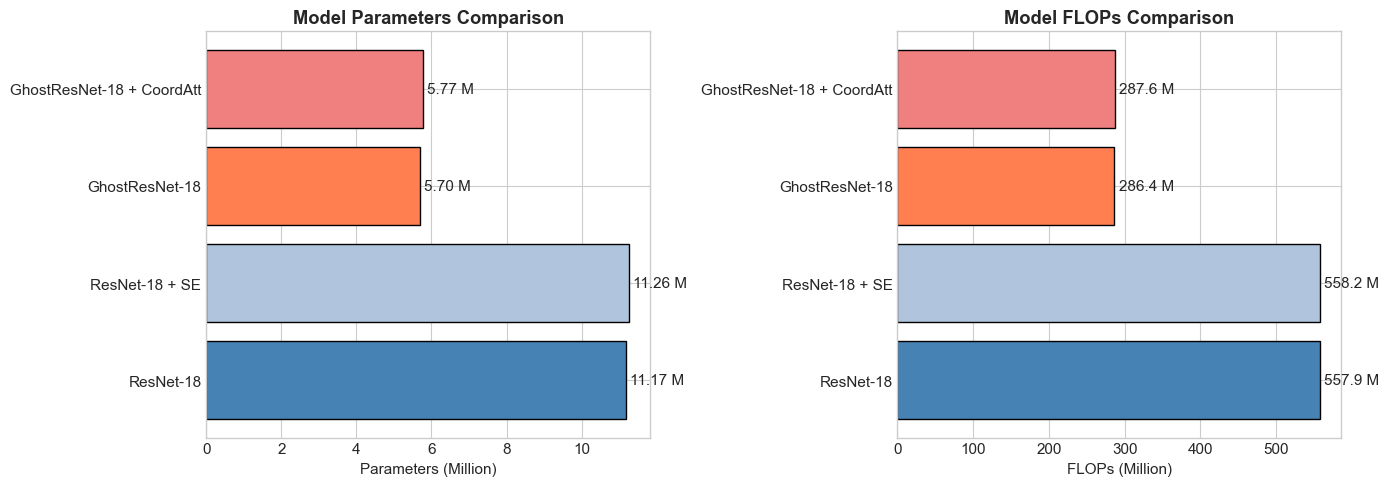


Efficiency Gains (vs ResNet-18 baseline)
ResNet-18 + SE:
  Params: -0.8%
  FLOPs:  -0.1%
GhostResNet-18:
  Params: +49.0%
  FLOPs:  +48.7%
GhostResNet-18 + CoordAtt:
  Params: +48.3%
  FLOPs:  +48.4%


In [7]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names = [r['name'] for r in results]
params = [r['params'] for r in results]
flops = [r['flops'] for r in results]

colors = ['steelblue', 'lightsteelblue', 'coral', 'lightcoral']

# Parameters
bars1 = axes[0].barh(names, params, color=colors, edgecolor='black')
axes[0].set_xlabel('Parameters (Million)')
axes[0].set_title('Model Parameters Comparison', fontweight='bold')
axes[0].bar_label(bars1, fmt='%.2f M', padding=3)

# FLOPs
bars2 = axes[1].barh(names, flops, color=colors, edgecolor='black')
axes[1].set_xlabel('FLOPs (Million)')
axes[1].set_title('Model FLOPs Comparison', fontweight='bold')
axes[1].bar_label(bars2, fmt='%.1f M', padding=3)

plt.tight_layout()
plt.savefig('../weights/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Print reduction
print(f"\n{'='*50}")
print("Efficiency Gains (vs ResNet-18 baseline)")
print(f"{'='*50}")
baseline_params = results[0]['params']
baseline_flops = results[0]['flops']

for r in results[1:]:
    param_red = (1 - r['params']/baseline_params) * 100
    flop_red = (1 - r['flops']/baseline_flops) * 100 if baseline_flops > 0 else 0
    print(f"{r['name']}:")
    print(f"  Params: {param_red:+.1f}%")
    print(f"  FLOPs:  {flop_red:+.1f}%")

## 4. GhostResNet Block Structure

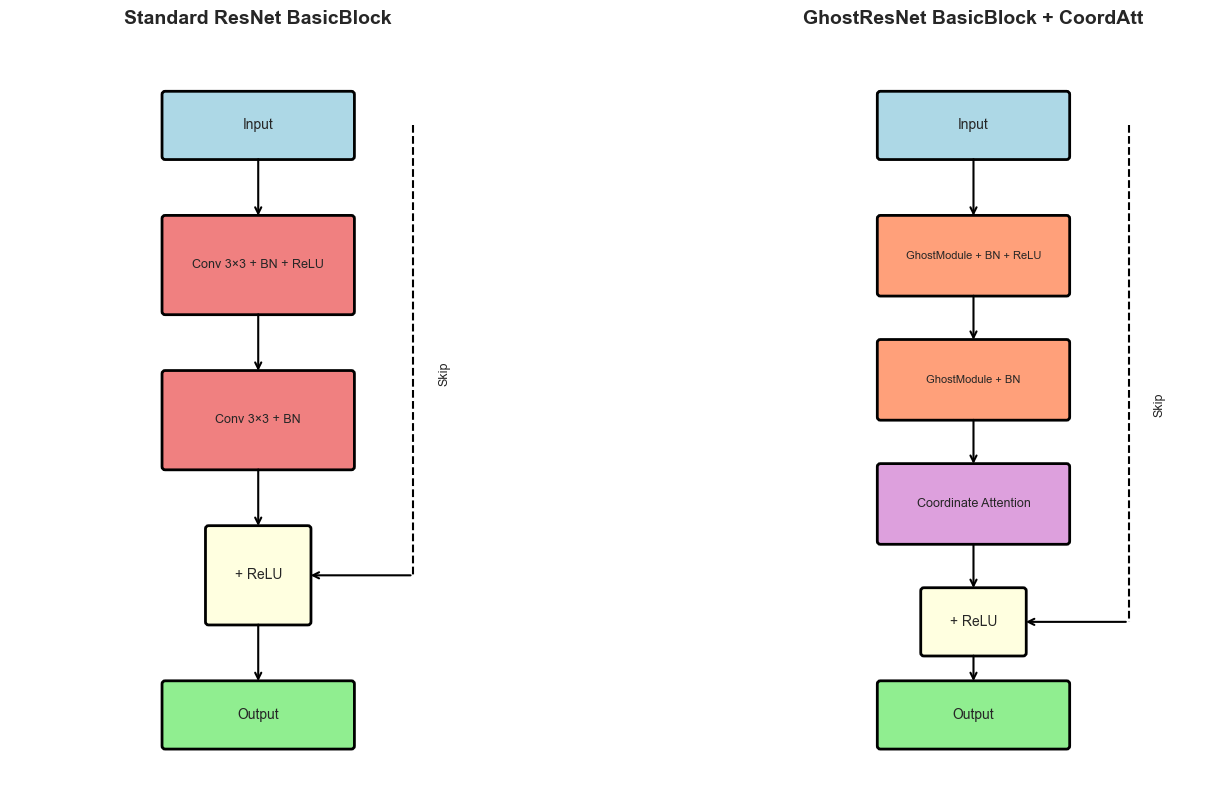

In [8]:
def visualize_ghost_block():
    """Visualize GhostResNet Basic Block"""
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # Standard ResNet Block
    ax = axes[0]
    ax.set_xlim(0, 8)
    ax.set_ylim(0, 12)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title('Standard ResNet BasicBlock', fontsize=14, fontweight='bold')
    
    # Input
    ax.add_patch(FancyBboxPatch((2.5, 10), 3, 1, boxstyle="round,pad=0.05",
                                 facecolor='lightblue', edgecolor='black', linewidth=2))
    ax.text(4, 10.5, 'Input', ha='center', va='center', fontsize=10)
    
    # Conv1
    ax.add_patch(FancyBboxPatch((2.5, 7.5), 3, 1.5, boxstyle="round,pad=0.05",
                                 facecolor='lightcoral', edgecolor='black', linewidth=2))
    ax.text(4, 8.25, 'Conv 3×3 + BN + ReLU', ha='center', va='center', fontsize=9)
    
    # Conv2
    ax.add_patch(FancyBboxPatch((2.5, 5), 3, 1.5, boxstyle="round,pad=0.05",
                                 facecolor='lightcoral', edgecolor='black', linewidth=2))
    ax.text(4, 5.75, 'Conv 3×3 + BN', ha='center', va='center', fontsize=9)
    
    # Add
    ax.add_patch(FancyBboxPatch((3.2, 2.5), 1.6, 1.5, boxstyle="round,pad=0.05",
                                 facecolor='lightyellow', edgecolor='black', linewidth=2))
    ax.text(4, 3.25, '+ ReLU', ha='center', va='center', fontsize=10)
    
    # Output
    ax.add_patch(FancyBboxPatch((2.5, 0.5), 3, 1, boxstyle="round,pad=0.05",
                                 facecolor='lightgreen', edgecolor='black', linewidth=2))
    ax.text(4, 1, 'Output', ha='center', va='center', fontsize=10)
    
    # Arrows
    ax.annotate('', xy=(4, 9), xytext=(4, 10), arrowprops=dict(arrowstyle='->', lw=1.5))
    ax.annotate('', xy=(4, 6.5), xytext=(4, 7.5), arrowprops=dict(arrowstyle='->', lw=1.5))
    ax.annotate('', xy=(4, 4), xytext=(4, 5), arrowprops=dict(arrowstyle='->', lw=1.5))
    ax.annotate('', xy=(4, 1.5), xytext=(4, 2.5), arrowprops=dict(arrowstyle='->', lw=1.5))
    
    # Skip connection
    ax.plot([6.5, 6.5], [10.5, 3.25], 'k--', lw=1.5)
    ax.annotate('', xy=(4.8, 3.25), xytext=(6.5, 3.25), arrowprops=dict(arrowstyle='->', lw=1.5))
    ax.text(7, 6.5, 'Skip', ha='center', va='center', fontsize=9, rotation=90)
    
    # Ghost ResNet Block
    ax = axes[1]
    ax.set_xlim(0, 8)
    ax.set_ylim(0, 12)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title('GhostResNet BasicBlock + CoordAtt', fontsize=14, fontweight='bold')
    
    # Input
    ax.add_patch(FancyBboxPatch((2.5, 10), 3, 1, boxstyle="round,pad=0.05",
                                 facecolor='lightblue', edgecolor='black', linewidth=2))
    ax.text(4, 10.5, 'Input', ha='center', va='center', fontsize=10)
    
    # Ghost1
    ax.add_patch(FancyBboxPatch((2.5, 7.8), 3, 1.2, boxstyle="round,pad=0.05",
                                 facecolor='lightsalmon', edgecolor='black', linewidth=2))
    ax.text(4, 8.4, 'GhostModule + BN + ReLU', ha='center', va='center', fontsize=8)
    
    # Ghost2
    ax.add_patch(FancyBboxPatch((2.5, 5.8), 3, 1.2, boxstyle="round,pad=0.05",
                                 facecolor='lightsalmon', edgecolor='black', linewidth=2))
    ax.text(4, 6.4, 'GhostModule + BN', ha='center', va='center', fontsize=8)
    
    # Attention
    ax.add_patch(FancyBboxPatch((2.5, 3.8), 3, 1.2, boxstyle="round,pad=0.05",
                                 facecolor='plum', edgecolor='black', linewidth=2))
    ax.text(4, 4.4, 'Coordinate Attention', ha='center', va='center', fontsize=9)
    
    # Add
    ax.add_patch(FancyBboxPatch((3.2, 2), 1.6, 1, boxstyle="round,pad=0.05",
                                 facecolor='lightyellow', edgecolor='black', linewidth=2))
    ax.text(4, 2.5, '+ ReLU', ha='center', va='center', fontsize=10)
    
    # Output
    ax.add_patch(FancyBboxPatch((2.5, 0.5), 3, 1, boxstyle="round,pad=0.05",
                                 facecolor='lightgreen', edgecolor='black', linewidth=2))
    ax.text(4, 1, 'Output', ha='center', va='center', fontsize=10)
    
    # Arrows
    ax.annotate('', xy=(4, 9), xytext=(4, 10), arrowprops=dict(arrowstyle='->', lw=1.5))
    ax.annotate('', xy=(4, 7), xytext=(4, 7.8), arrowprops=dict(arrowstyle='->', lw=1.5))
    ax.annotate('', xy=(4, 5), xytext=(4, 5.8), arrowprops=dict(arrowstyle='->', lw=1.5))
    ax.annotate('', xy=(4, 3), xytext=(4, 3.8), arrowprops=dict(arrowstyle='->', lw=1.5))
    ax.annotate('', xy=(4, 1.5), xytext=(4, 2), arrowprops=dict(arrowstyle='->', lw=1.5))
    
    # Skip connection
    ax.plot([6.5, 6.5], [10.5, 2.5], 'k--', lw=1.5)
    ax.annotate('', xy=(4.8, 2.5), xytext=(6.5, 2.5), arrowprops=dict(arrowstyle='->', lw=1.5))
    ax.text(7, 6, 'Skip', ha='center', va='center', fontsize=9, rotation=90)
    
    plt.tight_layout()
    plt.savefig('../weights/block_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_ghost_block()

## 5. Summary Table for Paper

In [9]:
import pandas as pd

# Create summary table
summary_data = {
    'Component': [
        'Ghost Module',
        'Coordinate Attention', 
        'Structured Pruning',
        'Knowledge Distillation',
        'INT8 Quantization'
    ],
    'Purpose': [
        'Reduce parameters via cheap operations',
        'Position-aware channel attention',
        'Remove redundant filters',
        'Transfer knowledge to smaller model',
        'Reduce precision for faster inference'
    ],
    'Param Reduction': [
        '~50%',
        '+2-3%',
        'Variable (target)',
        'Via student size',
        '~4x memory'
    ],
    'Accuracy Impact': [
        'Minimal (-1-2%)',
        'Improved (+1-2%)',
        'Depends on sparsity',
        'Student ≈ Teacher',
        'Minimal (-1%)',
    ]
}

df = pd.DataFrame(summary_data)
print("\n" + "="*80)
print("OPTIMIZATION TECHNIQUES SUMMARY")
print("="*80)
print(df.to_string(index=False))
print("="*80)

# Save as latex table
latex_table = df.to_latex(index=False, caption='Summary of Optimization Techniques')
print("\nLaTeX Table:")
print(latex_table)


OPTIMIZATION TECHNIQUES SUMMARY
             Component                                Purpose   Param Reduction     Accuracy Impact
          Ghost Module Reduce parameters via cheap operations              ~50%     Minimal (-1-2%)
  Coordinate Attention       Position-aware channel attention             +2-3%    Improved (+1-2%)
    Structured Pruning               Remove redundant filters Variable (target) Depends on sparsity
Knowledge Distillation    Transfer knowledge to smaller model  Via student size   Student ≈ Teacher
     INT8 Quantization  Reduce precision for faster inference        ~4x memory       Minimal (-1%)

LaTeX Table:
\begin{table}
\caption{Summary of Optimization Techniques}
\begin{tabular}{llll}
\toprule
Component & Purpose & Param Reduction & Accuracy Impact \\
\midrule
Ghost Module & Reduce parameters via cheap operations & ~50% & Minimal (-1-2%) \\
Coordinate Attention & Position-aware channel attention & +2-3% & Improved (+1-2%) \\
Structured Pruning & Remove